# Local Twist Analysis

In [70]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct
from scipy import odr

file_dir = "data100ns-2008"
output_dir = "output"

u_mean = md.Universe(file_dir + "/md_1.tpr", output_dir + "/md_1_mean.xtc")
chains = u_mean.select_atoms("protein").fragments

# "Nematic" Configuration - For Testing
u_start = md.Universe(file_dir + "/md_1.tpr", file_dir + "/md_1_noPBC.xtc")
u_start.trajectory[0] # Make Analysis of Starting Frame - Nematic
chains_start = u_start.select_atoms("protein").fragments

# COM for centering - Starting Position
com = u_start.select_atoms("protein").center_of_mass() / 10
com_v = np.array([com[0], com[1], 0.0])

In [71]:
mol = 0

In [108]:
# By Chains as we want the local twist
# Mean Data of the Molecule, we are not using cylindrical proj now
molchs_m = [[],[],[]]
molch = chains_start[3*mol:3*mol + 3]
for i in range(3):
    molchs_m[i] = molch[i].select_atoms("backbone").positions / 10
    molchs_m[i] = ct.remove_ends(0.5, molchs_m[i])

# Start Data
molchs_i = [[],[],[]]
molch = chains_start[3*mol:3*mol + 3]
for i in range(3):
    molchs_i[i] = molch[i].select_atoms("backbone").positions / 10 - com_v
    molchs_i[i] = ct.remove_ends(0.5, molchs_i[i])

Starting Position

In [109]:
psi_ch =[[],[],[]]
for i in range(3):
    rad, phi, z = ct.cyl_proj(molchs_i[i])
    arc = rad*phi
    atoms_pairs = len(rad) - 1
    psis = np.zeros(atoms_pairs)
    for a in range(atoms_pairs): # By pairs (consecutive)
        # Get angle with respect with the tangent plane (local cylinder)
        darc = arc[a+1] - arc[a]
        dz = z[a+1] - z[a]
        psis[a] = np.rad2deg(np.atan2(darc,dz)) # angle = arctan(co/ca) = arctan(tan(angle)) - we add the absolute given posible negative slope, we dont care
    psi_ch[i] = psis

In [105]:
def model_fn(p, x):
    # Coefficients p, x data
    m, c = p
    return m * x + c

Vis Starting Position

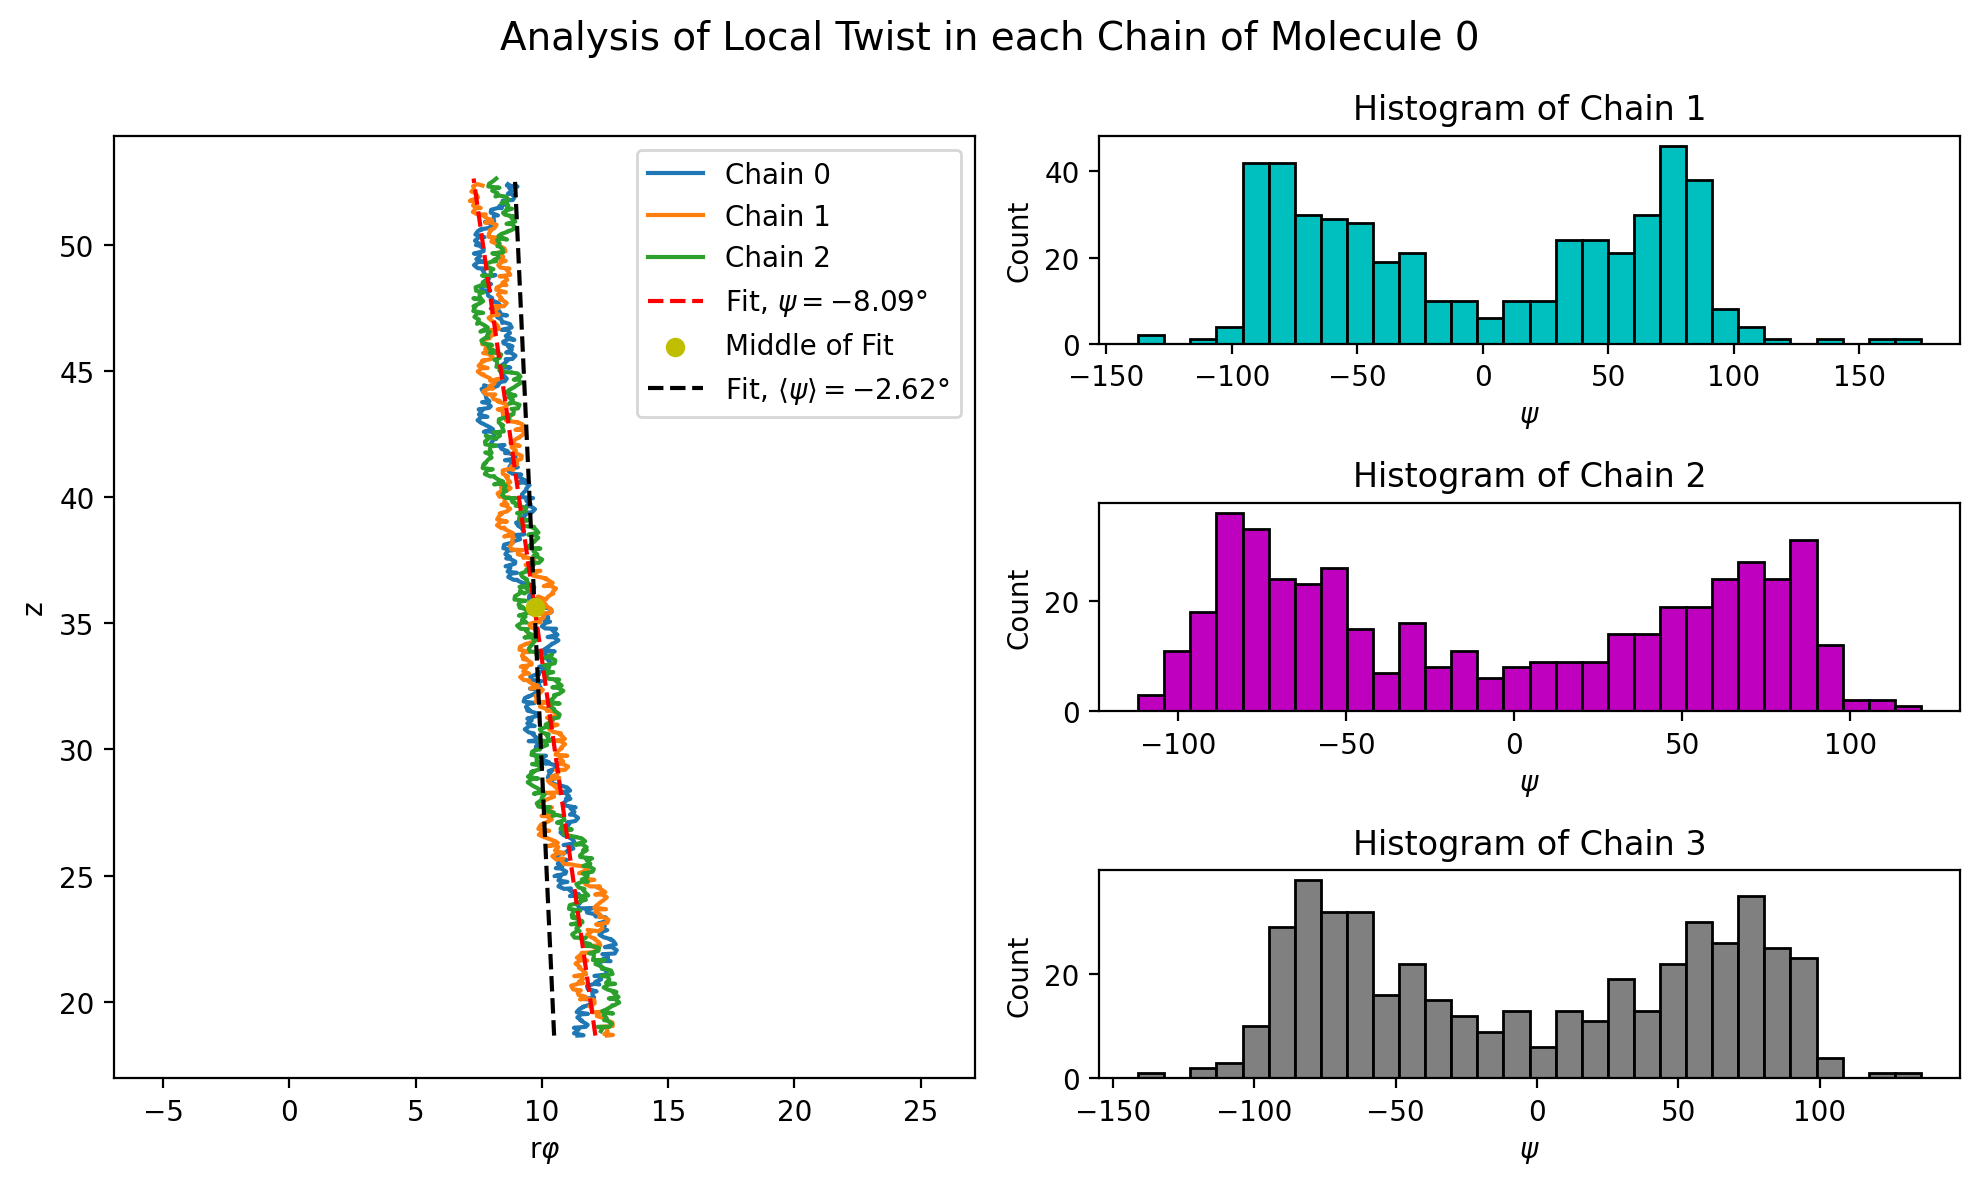

In [110]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 6), dpi=200)
gs = GridSpec(3, 2, figure=fig)  # 3 rows, 2 columns

# --- Phi vs Z --- 
ax0 = fig.add_subplot(gs[:, 0])
all_arc = []
all_z = []
for i in range(3):
    r, phi, z = ct.cyl_proj(molchs_i[i])
    arc = r*phi
    all_arc.append(arc)
    all_z.append(z)
    ax0.plot(arc, z, label=f"Chain {i}")

# --- Orthogonal Regression Fit ---
all_arc = np.concatenate(all_arc)
all_z   = np.concatenate(all_z)
order = np.argsort(all_z)
all_arc = all_arc[order]
all_z   = all_z[order]

model = odr.Model(model_fn)
data = odr.Data(all_z, all_arc)
odr_run = odr.ODR(data, model, beta0=[0.1, np.mean(all_arc)]) # Guess Parameters
res = odr_run.run()
psi_fit = np.rad2deg(np.atan(res.beta[0]))
ax0.plot(model_fn(res.beta, all_z), all_z, linestyle='dashed', color='r', label=rf'Fit, $\psi={psi_fit:.2f}\degree$')
# Middle
middle = [model_fn(res.beta, all_z[int(len(all_z)/2)]), all_z[int(len(all_z)/2)]]
ax0.scatter([middle[0]], [middle[1]], color='y', label='Middle of Fit', zorder=3)

# --- Mean Psi Fit ---
psi_ch1_m = np.mean(psi_ch[0])
psi_ch2_m = np.mean(psi_ch[1])
psi_ch3_m = np.mean(psi_ch[2])
psi_mean = np.mean([psi_ch1_m, psi_ch2_m, psi_ch3_m])
m_mean = np.tan(np.deg2rad(psi_mean))
b_mean = (res.beta[0] - m_mean)*all_z[int(len(all_z)/2)] + res.beta[1]
par_mean = [m_mean, b_mean]
ax0.plot(model_fn(par_mean, all_z), all_z, linestyle='dashed', color='k', label=rf'Fit, $\langle \psi \rangle={psi_mean:.2f}\degree$')

ax0.axis('equal')
ax0.set_xlabel(r'r$\varphi$')
ax0.set_ylabel(r'z')
ax0.legend()

# --- Local Psis Calculated ---
# --- Chain 1 ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(psi_ch[0], bins=30, color='c', edgecolor='k')
ax2.set_xlabel(r'$\psi$')
ax2.set_ylabel('Count')
ax2.set_title('Histogram of Chain 1')

# --- Chain 2 ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(psi_ch[1], bins=30, color='m', edgecolor='k')
ax3.set_xlabel(r'$\psi$')
ax3.set_ylabel('Count')
ax3.set_title('Histogram of Chain 2')

# --- Chain 2 ---
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(psi_ch[2], bins=30, color='grey', edgecolor='k')
ax4.set_xlabel(r'$\psi$')
ax4.set_ylabel('Count')
ax4.set_title('Histogram of Chain 3')

plt.suptitle(rf'Analysis of Local Twist in each Chain of Molecule {mol}', fontsize=14)
plt.tight_layout()
plt.show()

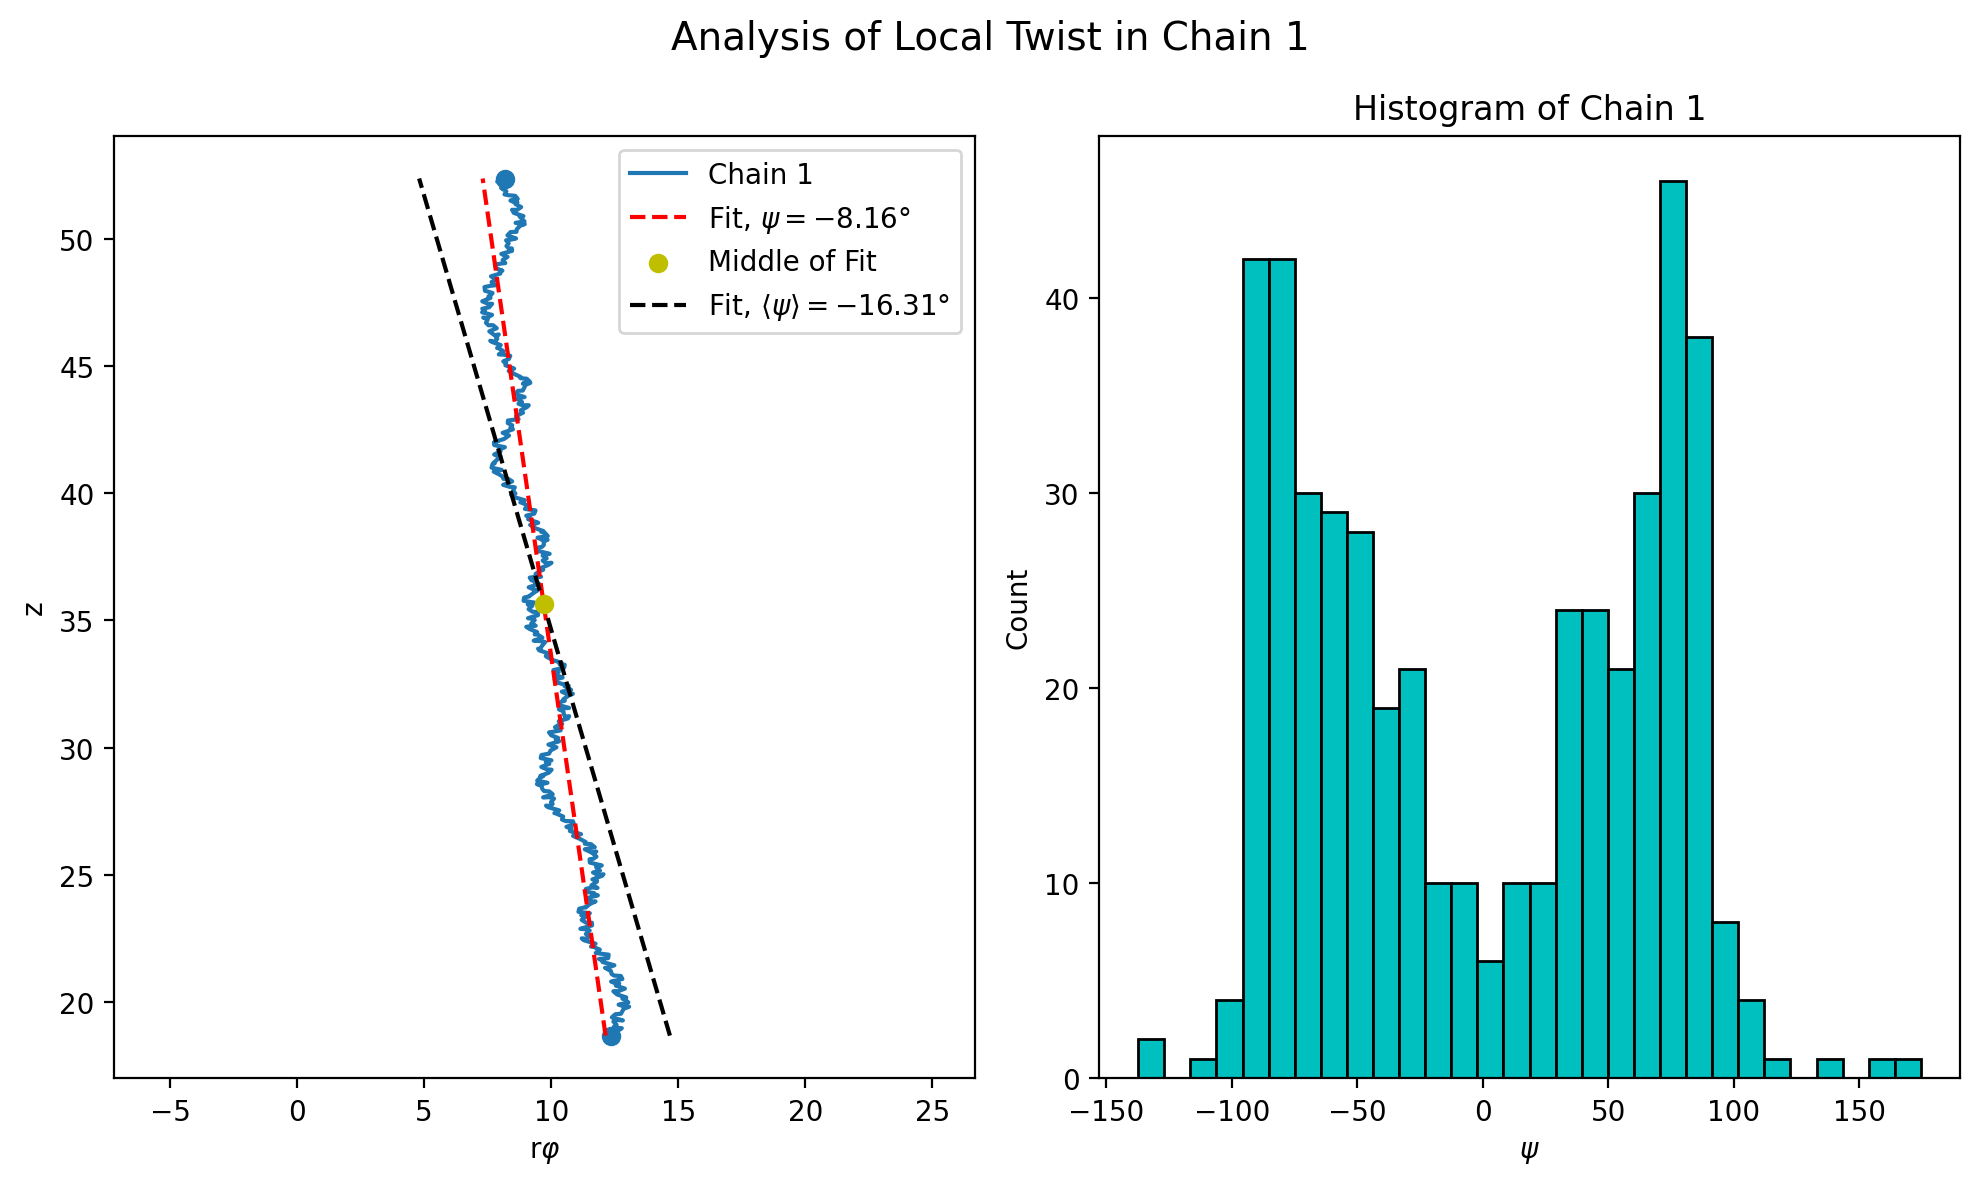

In [111]:
fig = plt.figure(figsize=(10, 6), dpi=200)
gs = GridSpec(1, 2, figure=fig)  # 3 rows, 2 columns

# --- Phi vs Z --- 
ax0 = fig.add_subplot(gs[0])
r, phi, z = ct.cyl_proj(molchs_i[0])
ax0.plot(arc, z, label=f"Chain 1")

# --- Orthogonal Regression Fit ---
model = odr.Model(model_fn)
data = odr.Data(z, arc)
odr_run = odr.ODR(data, model, beta0=[0.1, np.mean(arc)]) # Guess Parameters
res = odr_run.run()
psi_fit = np.rad2deg(np.atan(res.beta[0]))
ax0.plot(model_fn(res.beta, z), z, linestyle='dashed', color='r', label=rf'Fit, $\psi={psi_fit:.2f}\degree$')
# Middle
middle = [model_fn(res.beta, z[int(len(z)/2)]), z[int(len(z)/2)]]
ax0.scatter([middle[0]], [middle[1]], color='y', label='Middle of Fit', zorder=3)

# --- Mean Psi Fit ---
psi_mean = np.sum(psi_ch[0]) % 360 - 360
m_mean = np.tan(np.deg2rad(psi_mean))
b_mean = (res.beta[0] - m_mean)*z[int(len(z)/2)] + res.beta[1]
par_mean = [m_mean, b_mean]
ax0.plot(model_fn(par_mean, z), z, linestyle='dashed', color='k', label=rf'Fit, $\langle \psi \rangle={psi_mean:.2f}\degree$')

atoms_pairs = len(rad) - 1
darc = np.zeros(atoms_pairs)
dz = np.zeros(atoms_pairs)
for a in range(atoms_pairs): # By pairs (consecutive)
    # Get angle with respect with the tangent plane (local cylinder)
    darc[a] = arc[a+1] - arc[a]
    dz[a] = z[a+1] - z[a]

xe2e = [arc[0],arc[0] + np.sum(darc)]
ye2e = [z[0],z[0] + np.sum(dz)]
ax0.scatter(xe2e,ye2e)

ax0.axis('equal')
ax0.set_xlabel(r'r$\varphi$')
ax0.set_ylabel(r'z')
ax0.legend()

# --- Local Psis Calculated ---
# --- Chain 1 ---
ax2 = fig.add_subplot(gs[1])
ax2.hist(psi_ch[0], bins=30, color='c', edgecolor='k')
ax2.set_xlabel(r'$\psi$')
ax2.set_ylabel('Count')
ax2.set_title('Histogram of Chain 1')

plt.suptitle(rf'Analysis of Local Twist in Chain 1', fontsize=14)
plt.tight_layout()
plt.show()